# Module 02 — the opponent atlas: a data workflow on NASA's PAHdb computed library

**This table is parsed from the public NASA Ames PAHdb v4.00 computed library (DOI 10.3847/1538-4365/ae1c38). It is computed science data, not AI-generated, and it is the *opponent* of this project's pipeline, not its training data.**

Plan 05 (Δ-probed IR pipeline), Module 02 of the Udacity AI Mastery Capstone. The dataset is the tidy species table `species_pahdb_theoretical_4.00.csv` in this folder (10,749 rows × 27 columns), produced by `../build_opponent_atlas.py` from the library's XML download; the per-band table (2.5 million rows) is read from `../out/` for the plots that need it. Sources, versions and checksums are in `../PROVENANCE.md`; the written summary with citations is `../module_summary.pdf`.

Sections: **Setup · Ingestion · Cleaning · EDA · Visualizations · Summary**.

## Setup

In [1]:
import re
from pathlib import Path
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
DATA = Path("species_pahdb_theoretical_4.00.csv")      # the tabular dataset, beside this notebook
OUT = Path("..") / "out"; FIG = Path("figures"); FIG.mkdir(exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__, "| dataset:", DATA, DATA.exists())

pandas 3.0.3 | numpy 2.5.1 | dataset: species_pahdb_theoretical_4.00.csv True


## Ingestion

One row per molecular species: identifier (`uid`), formula, charge, element counts, symmetry, method and basis set (parsed from the Gaussian route line), the scale factors seen on its bands, the number of vibrational modes, and the references' DOIs.

In [2]:
sp = pd.read_csv(DATA, dtype={"uid": str, "charge": str})
print(sp.shape)
sp.head()

(10749, 27)


,uid,formula,charge,n_c,n_h,n_n,n_o,n_atoms,symmetry,method,basis,scales_seen,n_modes,weight,total_e,vib_e,n_solo,n_duo,n_trio,n_quartet,n_quintet,n_ch2,n_chx,dois,route,n_ch,n_ch3
0,430,C6H6O,0,6,6,0,1,13,1-A',RB3LYP,6-31g*,"0.9597,0.9691,0.9794",33,94.041860,-307.441141,65.0546,0,0,0,4,0,2,NaN,NaN,#b3lyp/6-31G* freq guess=check geom=check scf=...,0,0
1,428,C6H6O,0,6,6,0,1,13,1-A',RB3LYP,6-31g*,"0.9597,0.9691,0.9794",33,94.041860,-307.464860,65.7555,0,0,0,0,5,0,NaN,NaN,#b3lyp/6-31G* freq guess=check geom=check scf=...,0,0
2,431,C6H6O+,1,6,6,0,1,13,2-A,UB3LYP,6-31g*,"0.9597,0.9691,0.9794",33,94.041860,-307.129494,64.1714,0,0,0,4,0,2,NaN,NaN,#b3lyp/6-31G* freq guess=check geom=check scf=...,0,0
3,429,C6H6O+,1,6,6,0,1,13,"2-A""",UB3LYP,6-31g*,"0.9597,0.9691,0.9794",33,94.041860,-307.170513,65.7776,0,0,0,0,5,0,NaN,NaN,#b3lyp/6-31G* freq guess=check geom=check scf=...,0,0
4,432,C6H7O+,1,6,7,0,1,14,1-A',RB3LYP,6-31g*,"0.9597,0.9691,0.9794",36,95.049685,-307.794373,73.0861,0,0,0,4,0,2,NaN,NaN,#b3lyp/6-31G* freq guess=check geom=check scf=...,0,0


In [3]:
# secondary tables (derived by the same parser from the other two PAHdb libraries and the two other comparison lines)
bands = pd.read_csv(OUT / "theoretical_4.00/bands.csv.gz", dtype={"uid": str, "charge": str})
an_sp = pd.read_csv(OUT / "anharmonic_1.00/species.csv", dtype={"uid": str, "charge": str})
ex_sp = pd.read_csv(OUT / "experimental_3.10/species.csv", dtype={"uid": str, "charge": str})
lc_sp = pd.read_csv(OUT / "lineC_mai2025/species.csv", dtype={"uid": str})
cheap_sp = pd.read_csv(OUT / "cheapline_bos2025/species.csv", dtype={"uid": str, "charge": str})
print(f"bands: {len(bands):,} rows; anharmonic: {len(an_sp)} species; experimental: {len(ex_sp)}; line C: {len(lc_sp):,}; cheap line: {len(cheap_sp)}")
print("missing values per column (species):"); print(sp.isna().sum()[sp.isna().sum() > 0])

bands: 2,517,399 rows; anharmonic: 45 species; experimental: 84; line C: 1,705; cheap line: 81
missing values per column (species):
n_chx    10749
dois      3588
dtype: int64


## Cleaning

Two issues need handling before analysis. (1) The `formula` field carries the electric charge as a suffix (`C54H18-`, `C384H48+2`), so the same molecule appears under several formula strings; a clean `formula_core` column separates composition from charge, and the suffix is checked against the `charge` field. (2) The basis set lives only in a free-text Gaussian route line; the parser resolved it for most species, but 32 carry `chkbas` (basis read from a checkpoint) and must be flagged, not guessed. Isomers (same formula and charge, different `uid`) are kept: they are different molecules, not duplicates.

In [4]:
def split_charge_suffix(df: pd.DataFrame) -> pd.DataFrame:
    """Add `formula_core` (formula without its charge suffix) and `charge_from_formula` (the integer charge
    read from that suffix), and assert that the suffix agrees with the `charge` column for every row.

    The PAHdb formula string encodes charge as a trailing '+', '-', '+2', ...; leaving it in place would
    make one composition look like several. Returns a new DataFrame; the input is not modified.
    """
    out = df.copy()
    out["formula_core"] = out["formula"].str.replace(r"[+-]\d*$", "", regex=True)
    sign = out["formula"].str.extract(r"([+-])(\d*)$")
    q = sign[0].map({"+": 1, "-": -1}).fillna(0) * sign[1].replace("", "1").fillna("0").astype(int)
    out["charge_from_formula"] = q.astype(int)
    mismatch = (out["charge_from_formula"] != out["charge"].astype(int)).sum()
    assert mismatch == 0, f"{mismatch} rows where the formula suffix disagrees with the charge column"
    return out

def flag_unresolved_basis(df: pd.DataFrame) -> pd.DataFrame:
    """Add a boolean `basis_resolved` column and normalise the `basis` label.

    The basis set is parsed from the Gaussian route comment ('#becke3lyp/6-31G* freq ...'); species whose
    route reads the basis from a checkpoint ('chkbas') or names none get basis_resolved = False and the
    label '?', so that later groupings never silently assign them to a basis. Returns a new DataFrame.
    """
    out = df.copy()
    out["basis"] = out["basis"].fillna("?").str.lower()
    out["basis_resolved"] = ~out["basis"].isin(["?", ""])
    return out

sp = flag_unresolved_basis(split_charge_suffix(sp))
print("formula strings with a charge suffix:", (sp["formula"] != sp["formula_core"]).sum(), "of", len(sp))
print("basis resolved:", sp["basis_resolved"].sum(), "| unresolved:", (~sp["basis_resolved"]).sum())
print("uid unique:", sp["uid"].is_unique, "| bands with non-positive frequency:", int((bands.frequency_cm <= 0).sum()), "| negative intensities:", int((bands.intensity_km_mol < 0).sum()))
iso = sp.groupby(["formula_core", "charge"]).uid.nunique()
print("(formula, charge) groups:", len(iso), "| groups with > 1 uid (isomers, kept):", int((iso > 1).sum()), "| largest:", iso.idxmax(), int(iso.max()), "| species that would be lost if isomers were dropped:", int(len(sp) - len(iso)))
sp[~sp["basis_resolved"]][["uid", "formula", "charge", "n_c", "route"]].head(8)

formula strings with a charge suffix: 6270 of 10749
basis resolved: 10717 | unresolved: 32
uid unique: True | bands with non-positive frequency: 0 | negative intensities: 0
(formula, charge) groups: 1159 | groups with > 1 uid (isomers, kept): 638 | largest: ('C33H19', '0') 358 | species that would be lost if isomers were dropped: 9590


,uid,formula,charge,n_c,route
493,26,C24H12Mg+,1,24,# becke3lyp/chkbas geom=check guess=check freq
494,25,C24H12Mg+,1,24,# becke3lyp/chkbas freq scfcyc=255 scf=(novara...
495,24,C24H12Fe+,1,24,# becke3lyp/chkbas freq scfcyc=255 scf=(novara...
496,22,C24H12Fe+,1,24,# becke3lyp/chkbas scfcyc=256 freq\n# guess=ch...
503,28,C24H12Mg+2,2,24,# becke3lyp/chkbas geom=check guess=check freq
504,27,C24H12Mg+2,2,24,# becke3lyp/chkbas freq scfcyc=255 scf=(novara...
505,23,C24H12Fe+2,2,24,"# becke3lyp/chkbas scfcyc=255 scf=(novaracc,co..."
799,813,C28H16-,-1,28,#bp86/6-31+G* freq guess=check geom=check nofm...


## EDA

One function summarises coverage: how many species the library holds per rung of the project's ladder of test molecules. It is reused below for each comparison line; the size-by-charge and basis tables come from pandas directly.

In [5]:
LADDER = [("R0 benzene", ["C6H6"]), ("R1 naphthalene", ["C10H8"]), ("R2 pyrene", ["C16H10"]), ("R2 C18H12 isomers", ["C18H12"]),
          ("R3 coronene", ["C24H12"]), ("R4–R5 class (54–216 C)", (54, 216)), ("R6 class (≥ 300 C)", (300, 10_000))]

def coverage_summary(df: pd.DataFrame, n_c_col: str = "n_c", formula_col: str = "formula") -> pd.Series:
    """Count species per ladder rung for one comparison line.

    A rung is either a list of molecular formulas (matched on the formula without charge suffix, all charges
    counted) or an (n_min, n_max) carbon-count range. Returns a Series indexed by rung label.
    """
    core = df[formula_col].astype(str).str.replace(r"[+-]\d*$", "", regex=True)
    n_c = df[n_c_col].astype(int)
    out = {}
    for label, rule in LADDER:
        out[label] = int(core.isin(rule).sum()) if isinstance(rule, list) else int(((n_c >= rule[0]) & (n_c <= rule[1])).sum())
    return pd.Series(out, name="species")

bins = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400]
sp["n_c_bin"] = pd.cut(sp["n_c"], bins)
print(pd.crosstab(sp["n_c_bin"], sp["charge"]).reindex(columns=["-1", "0", "1", "2", "3"], fill_value=0))
print(); print(sp["basis"].value_counts())
print("smallest 4-31G species n_c =", sp.loc[sp.basis == "4-31g", "n_c"].min(), "| largest 6-31G* species n_c =", sp.loc[sp.basis == "6-31g*", "n_c"].max())
print("smallest species in the library:", sp.sort_values("n_c").formula.head(6).tolist())
coverage_summary(sp)

charge       -1     0    1     2  3
n_c_bin                            
(0, 10]       3    39   34    12  0
(10, 20]     11   114   87    59  0
(20, 30]     21   798   41   495  0
(30, 40]     82  1660  119  1130  0
(40, 50]    111   232  232   121  2
(50, 75]    248   574  587   268  5
(75, 100]   576   862  863   587  2
(100, 150]  167   186  187   182  0
(150, 200]    7     7    7     7  0
(200, 300]    5     6    5     6  0
(300, 400]    0     1    0     1  0

basis
6-31g*    10703
?            32
4-31g        14
Name: count, dtype: int64
smallest 4-31G species n_c = 212 | largest 6-31G* species n_c = 294
smallest species in the library: ['C6H6O', 'C6H6O', 'C6H6O+', 'C6H6O+', 'C6H7O+', 'C9H7']


R0 benzene                   0
R1 naphthalene               4
R2 pyrene                    7
R2 C18H12 isomers           16
R3 coronene                  5
R4–R5 class (54–216 C)    5110
R6 class (≥ 300 C)           2
Name: species, dtype: int64

## Visualizations

Five figures, each with a title and labelled axes. Figure 1: the library by size and charge. Figure 2: the scale factors as stored. Figure 3: band positions by family. Figure 4: coverage of the ladder by each comparison line. Figure 5: the largest species.

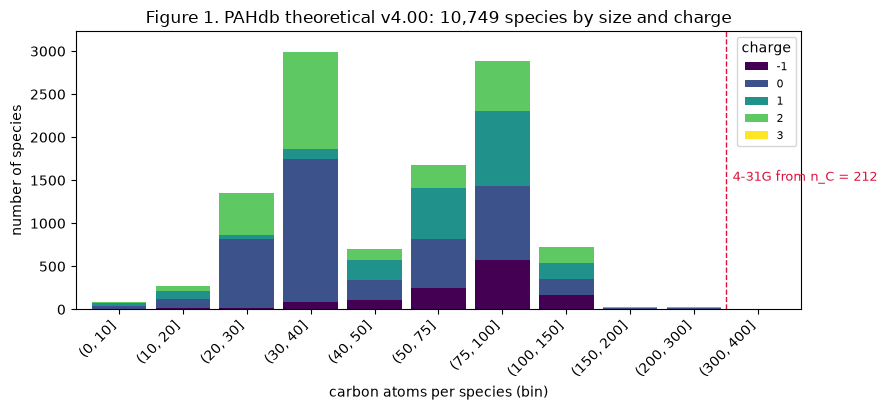

In [6]:
ct = pd.crosstab(sp["n_c_bin"], sp["charge"]).reindex(columns=["-1", "0", "1", "2", "3"], fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4.2))
ct.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="viridis")
ax.set_xlabel("carbon atoms per species (bin)"); ax.set_ylabel("number of species"); ax.set_title("Figure 1. PAHdb theoretical v4.00: 10,749 species by size and charge")
ax.set_ylim(0, ct.sum(axis=1).max() * 1.08); ax.axvline(9.5, color="crimson", ls="--", lw=1); ax.text(9.6, ct.values.max() * 0.9, "4-31G from n_C = 212", color="crimson", fontsize=9)
ax.legend(title="charge", fontsize=8); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); fig.savefig(FIG / "fig1_species_by_size_charge.png", dpi=140); plt.show()

*Figure 1 interpretation.* Most of the library sits between 20 and 100 carbon atoms; dications are as common as neutrals in the 20–40 range. The coarser 4-31G basis appears only from 212 carbons upward (14 species); the largest 6-31G* species has 294.

              min        max    count
scale                                
0.9794     0.1000  1088.2211  1407844
0.9691  1076.7810  1744.3742   875211
0.9597  2590.8549  4440.3359   210279
0.9563     0.9202  1062.4713    10731
0.9523  1058.1177  1656.8650     6982
0.9097  1637.6473  2139.7592     2488
0.9595  2933.4117  3148.5128     1158
0.9908     7.0839  1095.5235      583


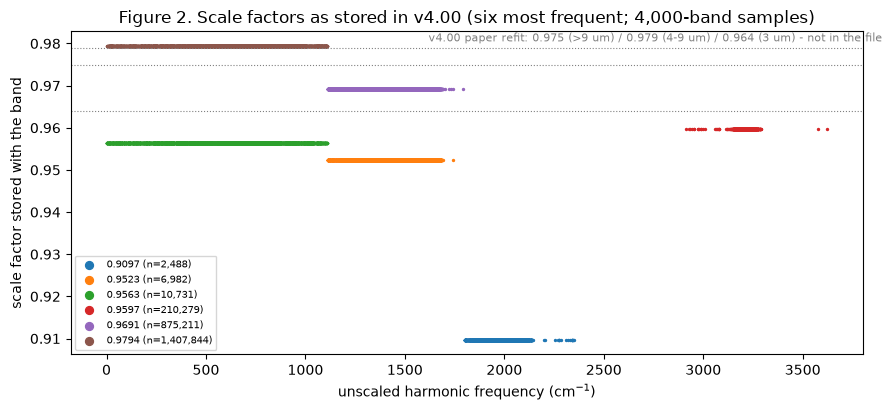

In [7]:
sc = bands.groupby("scale").frequency_cm.agg(["min", "max", "count"]).sort_values("count", ascending=False)
print(sc.head(8))
fig, ax = plt.subplots(figsize=(9, 4.2))
sub = bands[bands.scale.isin(sc.head(6).index)]
for s_, g in sub.groupby("scale"):
    ax.scatter(g.frequency_unscaled_cm.sample(min(len(g), 4000), random_state=0), [s_] * min(len(g), 4000), s=2, label=f"{s_} (n={len(g):,})")
for v in (0.964, 0.979, 0.975): ax.axhline(v, color="grey", ls=":", lw=0.8)
ax.text(3900, 0.9805, "v4.00 paper refit: 0.975 (>9 um) / 0.979 (4-9 um) / 0.964 (3 um) - not in the file", fontsize=8, color="grey", ha="right")
ax.set_xlabel("unscaled harmonic frequency (cm$^{-1}$)"); ax.set_ylabel("scale factor stored with the band"); ax.set_title("Figure 2. Scale factors as stored in v4.00 (six most frequent; 4,000-band samples)")
ax.legend(fontsize=7, markerscale=4, loc="lower left"); plt.tight_layout(); fig.savefig(FIG / "fig2_scale_factors_as_stored.png", dpi=140); plt.show()

*Figure 2 interpretation.* The stored factors are 0.9794 / 0.9691 / 0.9597 for the 6-31G* species and 0.9563 / 0.9523 / 0.9595 for the 4-31G species, in three frequency regions; these are the version 3.00 factors (Bauschlicher et al., 2018). None of the 2.5 million bands carries the 0.964 / 0.979 / 0.975 that the version 4.00 paper describes (Ricca et al., 2026).

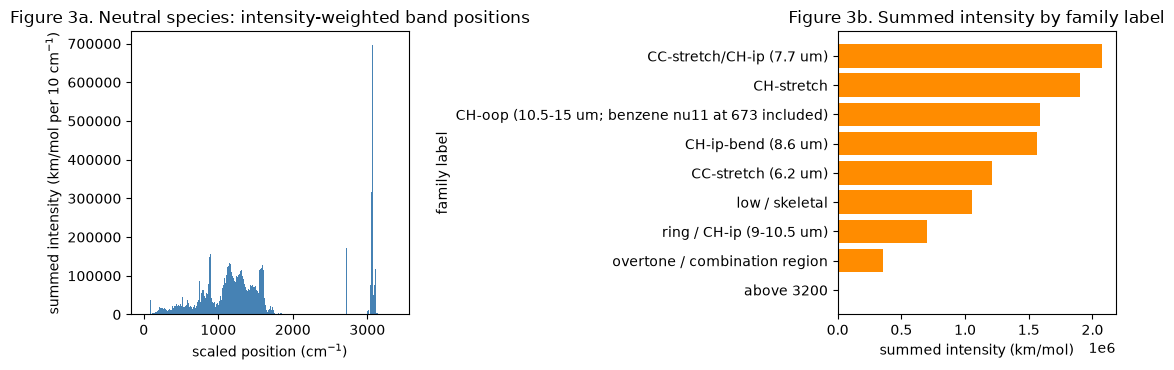

family
above 3200                                              2631.0
overtone / combination region                         356459.0
ring / CH-ip (9-10.5 um)                              697694.0
low / skeletal                                       1055432.0
CC-stretch (6.2 um)                                  1212116.0
CH-ip-bend (8.6 um)                                  1565027.0
CH-oop (10.5-15 um; benzene nu11 at 673 included)    1584844.0
CH-stretch                                           1899020.0
CC-stretch/CH-ip (7.7 um)                            2077226.0
Name: intensity_km_mol, dtype: float64


In [8]:
neutral = bands[bands.charge == "0"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(neutral.frequency_cm, bins=np.arange(0, 3400, 10), weights=neutral.intensity_km_mol, color="steelblue")
axes[0].set_xlabel("scaled position (cm$^{-1}$)"); axes[0].set_ylabel("summed intensity (km/mol per 10 cm$^{-1}$)"); axes[0].set_title("Figure 3a. Neutral species: intensity-weighted band positions")
fam = neutral.groupby("family").intensity_km_mol.sum().sort_values()
axes[1].barh(fam.index, fam.values, color="darkorange"); axes[1].set_xlabel("summed intensity (km/mol)"); axes[1].set_ylabel("family label"); axes[1].set_title("Figure 3b. Summed intensity by family label")
plt.tight_layout(); fig.savefig(FIG / "fig3_positions_by_family.png", dpi=140); plt.show()
print(fam.round(0))

*Figure 3 interpretation.* Intensity-weighted, the neutral library shows the familiar PAH pattern: the 7.7 µm C–C/C–H in-plane region carries the most summed intensity, then the C–H stretch near 3.3 µm, the C–H out-of-plane bands at 11–14 µm, the 8.6 µm bend and the 6.2 µm C–C stretch. The family label is a frequency-range rule, not an assignment.

                                       R0 benzene  R1 naphthalene  R2 pyrene  R2 C18H12 isomers  R3 coronene  R4–R5 class (54–216 C)  R6 class (≥ 300 C)
A: PAHdb theoretical 4.00                       0               4          7                 16            5                    5110                   2
B: PAHdb anharmonic 1.00                        1               1          2                  1            0                       0                   0
C: Mai 2025 MLMD                                0               1          2                  7            1                     388                   0
cheap: Bos 2025 SI                              0               1          3                  6            2                       0                   0
lab: PAHdb experimental 3.10 (matrix)           0               1          3                  6            2                       0                   0


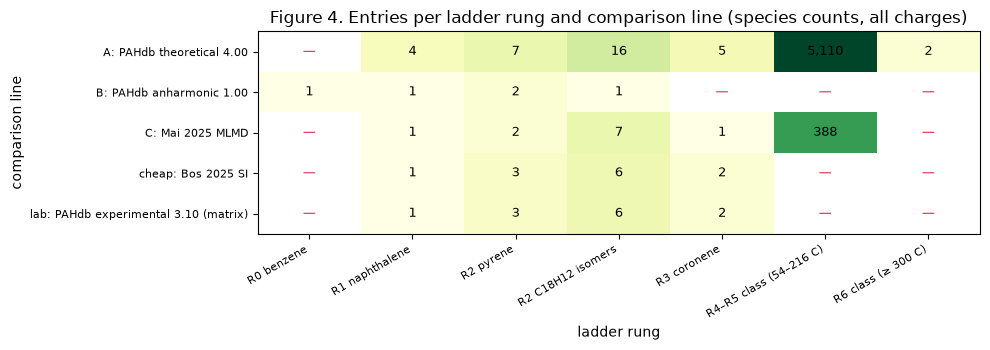

In [9]:
lines = {"A: PAHdb theoretical 4.00": sp, "B: PAHdb anharmonic 1.00": an_sp, "C: Mai 2025 MLMD": lc_sp, "cheap: Bos 2025 SI": cheap_sp, "lab: PAHdb experimental 3.10 (matrix)": ex_sp}
cov = pd.DataFrame({name: coverage_summary(df) for name, df in lines.items()}).T
print(cov)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.imshow(np.where(cov.values > 0, np.log10(cov.values + 1), np.nan), cmap="YlGn", aspect="auto")
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]; ax.text(j, i, f"{v:,}" if v else "—", ha="center", va="center", fontsize=9, color="black" if v else "crimson")
ax.set_xticks(range(cov.shape[1])); ax.set_xticklabels(cov.columns, rotation=30, ha="right", fontsize=8); ax.set_yticks(range(cov.shape[0])); ax.set_yticklabels(cov.index, fontsize=8)
ax.set_xlabel("ladder rung"); ax.set_ylabel("comparison line"); ax.set_title("Figure 4. Entries per ladder rung and comparison line (species counts, all charges)")
plt.tight_layout(); fig.savefig(FIG / "fig4_ladder_coverage.png", dpi=140); plt.show()

*Figure 4 interpretation.* Benzene (R0) is absent from every library except the anharmonic one; from naphthalene upward all lines have entries; above coronene only lines A and C remain, and above 216 carbons only line A. The competition thins out exactly where the project aims.

 uid   formula charge symmetry basis  n_modes          scales_seen
 617   C384H48      0    1-A1G 4-31g     1290 0.9523,0.9563,0.9595
4447 C384H48+2      2    3-B3G 4-31g     1290 0.9523,0.9563,0.9595


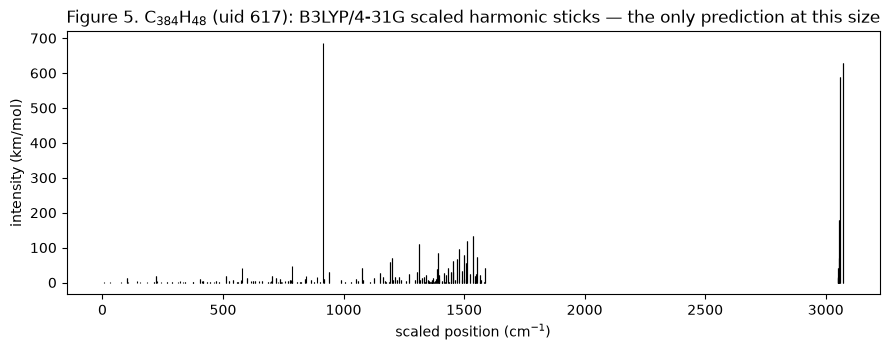

1290 modes; 230 with I > 1 km/mol; strongest:
 frequency_cm  intensity_km_mol symmetry                                            family
     913.0444          685.3361      A2U CH-oop (10.5-15 um; benzene nu11 at 673 included)
    3071.6238          630.1399      E1U                                        CH-stretch
    3071.6238          630.1314      E1U                                        CH-stretch
    3057.1625          588.3389      E1U                                        CH-stretch
    3057.1625          588.2814      E1U                                        CH-stretch
    3053.2920          178.3402      E1U                                        CH-stretch


In [10]:
c384 = sp[(sp.n_c >= 300) & (sp.n_c <= 400)][["uid", "formula", "charge", "symmetry", "basis", "n_modes", "scales_seen"]]; print(c384.to_string(index=False))
b617 = bands[bands.uid == "617"]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.vlines(b617.frequency_cm, 0, b617.intensity_km_mol, color="black", lw=0.8)
ax.set_xlabel("scaled position (cm$^{-1}$)"); ax.set_ylabel("intensity (km/mol)"); ax.set_title("Figure 5. C$_{384}$H$_{48}$ (uid 617): B3LYP/4-31G scaled harmonic sticks — the only prediction at this size")
plt.tight_layout(); fig.savefig(FIG / "fig5_c384h48_sticks.png", dpi=140); plt.show()
print(f"{len(b617)} modes; {int((b617.intensity_km_mol > 1).sum())} with I > 1 km/mol; strongest:")
print(b617.sort_values("intensity_km_mol", ascending=False).head(6)[["frequency_cm", "intensity_km_mol", "symmetry", "family"]].to_string(index=False))

*Figure 5 interpretation.* C₃₈₄H₄₈ is present (uid 617 neutral, uid 4447 dication) with 1,290 modes; the strongest sticks are the C–H out-of-plane band near 913 cm⁻¹ and the C–H stretch pair near 3060–3070 cm⁻¹. This answers the plan's open question (frozen-lines debt 6): the target class exists in the library, and line A is its only prediction.

## Summary

**What the dataset taught us.** The PAHdb computed library holds 10,749 species and 2,517,399 bands, most between 20 and 100 carbons, with neutrals and dications dominating. The basis set changes to 4-31G at 212 carbons, not at a round 200, and only 14 species live there. Our first test molecule, benzene, is not in the library at all (the smallest entries are phenol- and indene-like species; the smallest plain PAH is naphthalene), which is consistent with the project's decision to treat benzene as a calibration molecule rather than a target.

**Patterns and insights.** The stored scale factors are the version 3.00 factors (Bauschlicher et al., 2018), not the version 4.00 refit the current paper describes (Ricca et al., 2026); the difference is 4–15 cm⁻¹ at the band positions, the same size as the effects the project hopes to demonstrate. The project's decision, recorded before any result exists, is to score against the library as served and to print a column at the paper's factors beside it.

**Assumptions and limitations.** The family label is a frequency-range rule; a proper assignment would need the mode vectors, which the XML does not carry. The basis set is inferred from a free-text route line, and 32 species stay unresolved. We read the stored frequencies as scaled values because dividing by the stored factor returns numbers in the range of raw DFT results; this was checked on naphthalene's C–H stretch, not on every species.

**Surprising or unclear.** That a file and its describing paper disagree on the scale factors was unexpected; we have not asked the database team why, and the report treats it as a version-mismatch finding, not a fault. Nothing in this notebook is trained; it is exploration only, and it is the right-hand side of the project's later comparisons.